In [ ]:
!pip install thop

# Question 1 a)

In [ ]:
%%writefile data_loader.py
import torch
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms


def get_transforms(image_size: int = 32):
    """
    Get data transforms for MNIST/FashionMNIST.
    Converts 1-channel grayscale to 3-channel for ResNet compatibility.
    """
    return transforms.Compose([
        transforms.Resize((image_size, image_size)),
        transforms.ToTensor(),
        transforms.Lambda(lambda x: x.repeat(3, 1, 1)),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])


def load_dataset(dataset_name: str, data_dir: str, train_ratio: float, val_ratio: float,
                 test_ratio: float, image_size: int = 32, seed: int = 42):
    """
    Load and split dataset into train, validation, and test sets.
    """
    transform = get_transforms(image_size)

    # Select dataset
    if dataset_name.lower() == "mnist":
        full_train = datasets.MNIST(root=data_dir, train=True, download=True, transform=transform)
        test_dataset = datasets.MNIST(root=data_dir, train=False, download=True, transform=transform)
    elif dataset_name.lower() == "fashionmnist":
        full_train = datasets.FashionMNIST(root=data_dir, train=True, download=True, transform=transform)
        test_dataset = datasets.FashionMNIST(root=data_dir, train=False, download=True, transform=transform)
    else:
        raise ValueError(f"Unknown dataset: {dataset_name}. Choose 'mnist' or 'fashionmnist'")

    # Combine train and test to get full dataset
    full_dataset = torch.utils.data.ConcatDataset([full_train, test_dataset])
    total_size = len(full_dataset)

    train_size = int(train_ratio * total_size)
    val_size = int(val_ratio * total_size)
    test_size = total_size - train_size - val_size

    # Use seed for reproducible splits
    generator = torch.Generator().manual_seed(seed)
    train_dataset, val_dataset, test_dataset = random_split(
        full_dataset,
        [train_size, val_size, test_size],
        generator=generator
    )

    print(f"Dataset: {dataset_name.upper()} (image_size={image_size})")
    print(f"  Train: {len(train_dataset)} samples ({train_ratio*100:.0f}%)")
    print(f"  Val:   {len(val_dataset)} samples ({val_ratio*100:.0f}%)")
    print(f"  Test:  {len(test_dataset)} samples ({test_ratio*100:.0f}%)")

    return train_dataset, val_dataset, test_dataset


def create_dataloaders(train_dataset, val_dataset, test_dataset,
                       batch_size: int, pin_memory: bool, num_workers: int):
    """Create DataLoaders for train, validation, and test datasets."""
    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        pin_memory=pin_memory,
        num_workers=num_workers
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        pin_memory=pin_memory,
        num_workers=num_workers
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False,
        pin_memory=pin_memory,
        num_workers=num_workers
    )

    return train_loader, val_loader, test_loader


Writing data_loader.py


In [ ]:
%%writefile models.py
import torch.nn as nn
from torchvision import models


def get_model(model_name: str, num_classes: int = 10, pretrained: bool = False):
    if model_name.lower() == "resnet18":
        model = models.resnet18(weights=None)
    elif model_name.lower() == "resnet34":
        model = models.resnet34(weights=None)
    elif model_name.lower() == "resnet50":
        model = models.resnet50(weights=None)
    else:
        raise ValueError(f"Unknown model: {model_name}. Choose 'resnet18', 'resnet34', or 'resnet50'")

    # Modify the final fully connected layer for 10 classes
    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, num_classes)

    print(f"Model: {model_name.upper()}")
    print(f"  Pretrained: {pretrained}")
    print(f"  Output classes: {num_classes}")
    print(f"  Total parameters: {sum(p.numel() for p in model.parameters()):,}")

    return model


def get_optimizer(model, optimizer_name: str, learning_rate: float):
    import torch.optim as optim

    if optimizer_name.lower() == "sgd":
        optimizer = optim.SGD(model.parameters(), lr=learning_rate, momentum=0.9)
    elif optimizer_name.lower() == "adam":
        optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    else:
        raise ValueError(f"Unknown optimizer: {optimizer_name}. Choose 'sgd' or 'adam'")

    print(f"Optimizer: {optimizer_name.upper()}, LR: {learning_rate}")

    return optimizer


Writing models.py


In [ ]:
%%writefile train.py
# Argument	Description
# --dataset:mnist or fashionmnist
# --model:resnet18 or resnet50 or resnet34
# --batch_size:int
# --epochs:int
# --optimizer:sgd or adam
# --lr:float
# --scheduler:none, cosine, or plateau
# --pin_memory:bool
# --seed:int


import argparse
import os
import random
import time
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.optim.lr_scheduler as lr_scheduler
import yaml
from torch.amp import GradScaler, autocast
from tqdm import tqdm

from data_loader import create_dataloaders, load_dataset
from models import get_model, get_optimizer


def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    print(f"Random seed set to: {seed}")


def get_scheduler(optimizer, scheduler_name: str, epochs: int, scheduler_params: dict):
    """Create learning rate scheduler."""
    if scheduler_name == "none" or scheduler_name is None:
        return None
    elif scheduler_name == "cosine":
        return lr_scheduler.CosineAnnealingLR(
            optimizer,
            T_max=epochs,
            eta_min=scheduler_params.get('eta_min', 1e-6)
        )
    elif scheduler_name == "plateau":
        return lr_scheduler.ReduceLROnPlateau(
            optimizer,
            mode='max',  # Maximize validation accuracy
            patience=scheduler_params.get('patience', 2),
            factor=scheduler_params.get('factor', 0.5)
        )
    else:
        raise ValueError(f"Unknown scheduler: {scheduler_name}. Choose 'none', 'cosine', or 'plateau'")


def train_epoch(model, train_loader, criterion, optimizer, device, scaler, use_amp):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    pbar = tqdm(train_loader, desc="Training", leave=False)
    for inputs, labels in pbar:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()

        with autocast(device_type='cuda', enabled=use_amp):
            outputs = model(inputs)
            loss = criterion(outputs, labels)

        if use_amp:
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

        pbar.set_postfix({"loss": f"{loss.item():.4f}", "acc": f"{100.0*correct/total:.2f}%"})

    epoch_loss = running_loss / total
    epoch_acc = 100.0 * correct / total

    return epoch_loss, epoch_acc


def evaluate(model, data_loader, criterion, device, use_amp, desc="Evaluating"):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    pbar = tqdm(data_loader, desc=desc, leave=False)
    with torch.no_grad():
        for inputs, labels in pbar:
            inputs, labels = inputs.to(device), labels.to(device)

            with autocast(device_type='cuda', enabled=use_amp):
                outputs = model(inputs)
                loss = criterion(outputs, labels)

            running_loss += loss.item() * inputs.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

            pbar.set_postfix({"acc": f"{100.0*correct/total:.2f}%"})

    epoch_loss = running_loss / total
    epoch_acc = 100.0 * correct / total

    return epoch_loss, epoch_acc


def train(config: dict):
    seed = config.get('experiment', {}).get('seed', 35)
    set_seed(seed)

    dataset_name = config['dataset']['name']
    data_dir = config['dataset']['data_dir']
    train_ratio = config['dataset']['train_ratio']
    val_ratio = config['dataset']['val_ratio']
    test_ratio = config['dataset']['test_ratio']
    image_size = config['dataset'].get('image_size', 32)

    model_name = config['model']['name']
    pretrained = config['model']['pretrained']
    num_classes = config['model']['num_classes']

    batch_size = config['training']['batch_size']
    epochs = config['training']['epochs']
    optimizer_name = config['training']['optimizer']
    learning_rate = config['training']['learning_rate']
    scheduler_name = config['training'].get('scheduler', 'none')
    scheduler_params = config['training'].get('scheduler_params', {})
    early_stop_patience = config['training'].get('early_stop_patience', 5)
    save_best_model = config['training'].get('save_best_model', True)
    checkpoint_dir = config['training'].get('checkpoint_dir', './checkpoints')

    device = config['system']['device']
    pin_memory = config['system']['pin_memory']
    num_workers = config['system']['num_workers']
    use_amp = config['system']['use_amp']

    print("=" * 60)
    print("TRAINING CONFIGURATION")
    print("=" * 60)

    # Setup device
    if device == "cuda" and not torch.cuda.is_available():
        print("CUDA not available, falling back to CPU")
        device = "cpu"
    device = torch.device(device)
    print(f"Device: {device}")

    # Load data
    train_dataset, val_dataset, test_dataset = load_dataset(
        dataset_name, data_dir, train_ratio, val_ratio, test_ratio, image_size, seed
    )

    train_loader, val_loader, test_loader = create_dataloaders(
        train_dataset, val_dataset, test_dataset,
        batch_size, pin_memory, num_workers
    )

    # Create model
    model = get_model(model_name, num_classes, pretrained)
    model = model.to(device)

    # Calculate FLOPs
    try:
        from thop import profile
        dummy_input = torch.randn(1, 3, image_size, image_size).to(device)
        flops, params = profile(model, inputs=(dummy_input,), verbose=False)
        flops_str = f"{flops/1e9:.2f}G"
        print(f"  FLOPs: {flops_str}")
    except ImportError:
        flops = 0
        flops_str = "N/A (install thop)"
        print(f"  FLOPs: {flops_str}")
    except Exception as e:
        flops = 0
        flops_str = f"Error: {e}"

    # Setup optimizer, scheduler and loss
    optimizer = get_optimizer(model, optimizer_name, learning_rate)
    scheduler = get_scheduler(optimizer, scheduler_name, epochs, scheduler_params)
    criterion = nn.CrossEntropyLoss()

    # Setup AMP
    scaler = GradScaler('cuda', enabled=use_amp)
    print(f"AMP enabled: {use_amp}")
    print(f"Pin memory: {pin_memory}")
    print(f"Batch size: {batch_size}")
    print(f"Epochs: {epochs}")
    print(f"Scheduler: {scheduler_name}")
    print(f"Early stopping patience: {early_stop_patience}")
    print(f"Save best model: {save_best_model}")
    print("=" * 60)

    # Create checkpoint directory
    if save_best_model:
        os.makedirs(checkpoint_dir, exist_ok=True)
        best_model_path = os.path.join(checkpoint_dir, f"best_{model_name}_{dataset_name}_seed{seed}.pt")

    # Training loop
    best_val_acc = 0.0
    best_model_state = None
    epochs_without_improvement = 0
    total_train_time_ms = 0.0

    for epoch in range(epochs):
        start_time = time.time()

        # Train
        train_start = time.time()
        train_loss, train_acc = train_epoch(
            model, train_loader, criterion, optimizer, device, scaler, use_amp
        )
        train_time_ms = (time.time() - train_start) * 1000
        total_train_time_ms += train_time_ms

        # Validate
        val_loss, val_acc = evaluate(model, val_loader, criterion, device, use_amp, desc="Validating")

        elapsed = time.time() - start_time

        # Update scheduler
        current_lr = optimizer.param_groups[0]['lr']
        if scheduler is not None:
            if scheduler_name == "plateau":
                scheduler.step(val_acc)
            else:
                scheduler.step()

        # Check for improvement
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            epochs_without_improvement = 0
            best_model_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

            if save_best_model:
                torch.save(best_model_state, best_model_path)
                print(f"Epoch [{epoch+1}/{epochs}] | "
                      f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}% | "
                      f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}% | "
                      f"LR: {current_lr:.6f} | Time: {elapsed:.1f}s | ✓ Best")
        else:
            epochs_without_improvement += 1
            print(f"Epoch [{epoch+1}/{epochs}] | "
                  f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}% | "
                  f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}% | "
                  f"LR: {current_lr:.6f} | Time: {elapsed:.1f}s | No improv ({epochs_without_improvement}/{early_stop_patience})")

        # Early stopping
        if early_stop_patience > 0 and epochs_without_improvement >= early_stop_patience:
            print(f"\nEarly stopping triggered after {epoch+1} epochs")
            break

    # Load best model for final evaluation
    if best_model_state is not None:
        model.load_state_dict(best_model_state)
        print("\nLoaded best model for final evaluation")

    # Final test evaluation
    print("=" * 60)
    print("FINAL TEST EVALUATION")
    print("=" * 60)

    test_loss, test_acc = evaluate(model, test_loader, criterion, device, use_amp, desc="Testing")

    print(f"Test Loss: {test_loss:.4f}")
    print(f"Test Accuracy: {test_acc:.2f}%")
    print("=" * 60)

    results = {
        'dataset': dataset_name,
        'model': model_name,
        'batch_size': batch_size,
        'optimizer': optimizer_name,
        'learning_rate': learning_rate,
        'scheduler': scheduler_name,
        'epochs': epochs,
        'seed': seed,
        'pin_memory': pin_memory,
        'best_val_acc': best_val_acc,
        'test_acc': test_acc,
        'train_time_ms': total_train_time_ms,
        'flops': flops_str
    }

    return results


def load_config(config_path: str) -> dict:
    with open(config_path, 'r') as f:
        config = yaml.safe_load(f)
    return config


def check_if_exists(config: dict, log_file: str = 'results.csv') -> bool:
    """Check if this hyperparameter combination already exists in the results CSV."""
    import csv
    import fcntl

    if not os.path.exists(log_file):
        return False

    # Extract the key hyperparameters to check
    dataset = config['dataset']['name']
    model = config['model']['name']
    batch_size = config['training']['batch_size']
    optimizer = config['training']['optimizer']
    learning_rate = config['training']['learning_rate']
    scheduler = config['training'].get('scheduler', 'none')
    epochs = config['training']['epochs']
    seed = config.get('experiment', {}).get('seed', 35)

    if scheduler == 'plateau':
        return True

    lock_file = log_file + '.lock'

    # Acquire shared lock for reading
    with open(lock_file, 'w') as lock:
        fcntl.flock(lock.fileno(), fcntl.LOCK_SH)
        try:
            with open(log_file, 'r', newline='') as f:
                reader = csv.DictReader(f)
                for row in reader:
                    try:
                        if (row['dataset'] == dataset and
                            row['model'] == model and
                            int(row['batch_size']) == batch_size and
                            row['optimizer'] == optimizer and
                            float(row['learning_rate']) == learning_rate and
                            row['scheduler'] == scheduler and
                            int(row['epochs']) == epochs and
                            int(row['seed']) == seed):
                            return True
                    except (KeyError, ValueError):
                        # Skip malformed rows
                        continue
        finally:
            fcntl.flock(lock.fileno(), fcntl.LOCK_UN)

    return False


def log_results(results: dict, log_file: str = 'results.csv'):
    """Append results to CSV log file with file locking for concurrent access."""
    import csv
    import fcntl

    lock_file = log_file + '.lock'

    # Acquire exclusive lock for writing
    with open(lock_file, 'w') as lock:
        fcntl.flock(lock.fileno(), fcntl.LOCK_EX)
        try:
            file_exists = os.path.exists(log_file)

            with open(log_file, 'a', newline='') as f:
                writer = csv.DictWriter(f, fieldnames=results.keys())
                if not file_exists:
                    writer.writeheader()
                writer.writerow(results)
        finally:
            fcntl.flock(lock.fileno(), fcntl.LOCK_UN)

    print(f"Results logged to: {log_file}")


def main():
    parser = argparse.ArgumentParser(description='MNIST/FashionMNIST Training')
    parser.add_argument('--config', type=str, default='config.yaml',
                        help='Path to configuration YAML file')

    # Override options
    parser.add_argument('--dataset', type=str, help='Override dataset name')
    parser.add_argument('--model', type=str, help='Override model name')
    parser.add_argument('--batch_size', type=int, help='Override batch size')
    parser.add_argument('--epochs', type=int, help='Override epochs')
    parser.add_argument('--optimizer', type=str, help='Override optimizer')
    parser.add_argument('--lr', type=float, help='Override learning rate')
    parser.add_argument('--scheduler', type=str, help='Override scheduler (none/cosine/plateau)')
    parser.add_argument('--pin_memory', type=str, help='Override pin_memory (true/false)')
    parser.add_argument('--seed', type=int, help='Override random seed (single seed mode)')
    parser.add_argument('--multi_seed', type=int, nargs='+', help='Run with multiple seeds (e.g., --multi_seed 35 78 13)')
    parser.add_argument('--log_file', type=str, default='results.csv', help='CSV file to log results')

    args = parser.parse_args()

    # Load base config
    config = load_config(args.config)

    # Apply overrides
    if args.dataset:
        config['dataset']['name'] = args.dataset
    if args.model:
        config['model']['name'] = args.model
    if args.batch_size:
        config['training']['batch_size'] = args.batch_size
    if args.epochs:
        config['training']['epochs'] = args.epochs
    if args.optimizer:
        config['training']['optimizer'] = args.optimizer
    if args.lr:
        config['training']['learning_rate'] = args.lr
    if args.scheduler:
        config['training']['scheduler'] = args.scheduler
    if args.pin_memory:
        config['system']['pin_memory'] = args.pin_memory.lower() == 'true'

    # Determine seeds to run
    if args.multi_seed:
        seeds = args.multi_seed  # Use seeds provided via CLI
    elif args.seed:
        seeds = [args.seed]
    else:
        seeds = [config.get('experiment', {}).get('seed', 35)]

    all_results = []

    for seed in seeds:
        config['experiment']['seed'] = seed

        # Check if this configuration already exists in results
        if check_if_exists(config, args.log_file):
            print(f"\n{'='*60}")
            print(f"SKIPPING SEED {seed} - Already exists in {args.log_file}")
            print(f"  Dataset: {config['dataset']['name']}, Model: {config['model']['name']}")
            print(f"  Batch: {config['training']['batch_size']}, Optimizer: {config['training']['optimizer']}")
            print(f"  LR: {config['training']['learning_rate']}, Scheduler: {config['training'].get('scheduler', 'none')}")
            print(f"  Epochs: {config['training']['epochs']}")
            print(f"{'='*60}")
            continue

        print(f"\n{'='*60}")
        print(f"RUNNING WITH SEED: {seed}")
        print(f"{'='*60}")

        results = train(config)
        results['timestamp'] = time.strftime('%Y-%m-%d %H:%M:%S')
        all_results.append(results)

        # Log each result
        log_results(results, args.log_file)

    # Print summary if multiple seeds
    if len(seeds) > 1:
        test_accs = [r['test_acc'] for r in all_results]
        val_accs = [r['best_val_acc'] for r in all_results]

        print(f"\n{'='*60}")
        print("MULTI-SEED SUMMARY")
        print(f"{'='*60}")
        print(f"Seeds: {seeds}")
        print(f"Test Accuracies: {[f'{acc:.2f}%' for acc in test_accs]}")
        print(f"Mean Test Accuracy: {np.mean(test_accs):.2f}% ± {np.std(test_accs):.2f}%")
        print(f"Mean Val Accuracy: {np.mean(val_accs):.2f}% ± {np.std(val_accs):.2f}%")
        print(f"{'='*60}")

    return all_results


if __name__ == "__main__":
    main()



Writing train.py


In [ ]:
%%writefile config.yaml
experiment:
  name: "mnist_resnet_experiment"
  seed: 42
  seeds_list: [42, 123, 456]
dataset:
  name: "mnist"  # Options: mnist, fashionmnist
  data_dir: "./data"
  train_ratio: 0.7
  val_ratio: 0.1
  test_ratio: 0.2
  image_size: 28

model:
  name: "resnet18"  # resnet18, resnet50, resnet34
  pretrained: false
  num_classes: 10

training:
  batch_size: 32
  epochs: 10
  optimizer: "adam"  # Options: sgd, adam
  learning_rate: 0.001
  scheduler: "none"  # none, cosine, plateau
  scheduler_params:
    # For cosine:
    eta_min: 0.00001
    # For plateau:
    patience: 2
    factor: 0.5
  early_stop_patience: 4
  save_best_model: true
  checkpoint_dir: "./checkpoints"

system:
  device: "cuda"
  pin_memory: true
  num_workers: 4
  use_amp: true


Writing config.yaml


In [ ]:
%%writefile run_experiments.sh
#!/bin/bash

# Define the lists of hyperparameters
DATASETS=("mnist" "fashionmnist")
MODELS=("resnet18" "resnet50")
EPOCHS_LIST=(10 20)
BATCH_SIZES=(16 32)
OPTIMIZERS=("sgd" "adam")
LEARNING_RATES=(0.001 0.0001)
SCHEDULERS=("none" "cosine")

# Fixed arguments
PIN_MEMORY="True"

# Loops to generate and execute all command combinations
for dataset in "${DATASETS[@]}"; do
  for model in "${MODELS[@]}"; do
    for epochs in "${EPOCHS_LIST[@]}"; do
      for batch_size in "${BATCH_SIZES[@]}"; do
        for optimizer in "${OPTIMIZERS[@]}"; do
          for lr in "${LEARNING_RATES[@]}"; do
            for scheduler in "${SCHEDULERS[@]}"; do

                echo "Running: Dataset=$dataset | Model=$model | Epochs=$epochs | Batch=$batch_size | Opt=$optimizer | LR=$lr | Sched=$scheduler"

                CUDA_VISIBLE_DEVICES=0 uv run train.py \
                  --dataset "$dataset" \
                  --model "$model" \
                  --batch_size "$batch_size" \
                  --epochs "$epochs" \
                  --optimizer "$optimizer" \
                  --lr "$lr" \
                  --scheduler "$scheduler" \
                  --pin_memory "$PIN_MEMORY" \
                  --multi_seed 35 78 13

            done
          done
        done
      done
    done
  done
done

Writing run_experiments.sh


In [ ]:
# !bash run_experiments.sh

Running: Dataset=mnist | Model=resnet18 | Epochs=10 | Batch=16 | Opt=sgd | LR=0.001 | Sched=none
Traceback (most recent call last):
  File "/content/train.py", line 26, in <module>
    from data_loader import create_dataloaders, load_dataset
  File "/content/data_loader.py", line 3, in <module>
    from torchvision import datasets, transforms
  File "/usr/local/lib/python3.12/dist-packages/torchvision/__init__.py", line 10, in <module>
    from torchvision import _meta_registrations, datasets, io, models, ops, transforms, utils  # usort:skip
    ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/torchvision/models/__init__.py", line 2, in <module>
    from .convnext import *
  File "/usr/local/lib/python3.12/dist-packages/torchvision/models/convnext.py", line 9, in <module>
    from ..ops.misc import Conv2dNormActivation, Permute
  File "/usr/local/lib/python3.12/dist-packages/torchvision/ops/__init_

Question 1b

In [ ]:
import time
import pandas as pd
import numpy as np
from torchvision import datasets, transforms
from sklearn import svm
from sklearn.metrics import accuracy_score

def load_svm_data(name, max_train=10000, max_test=2000):
    if name == "MNIST":
        train_data = datasets.MNIST("./data", train=True, download=True, transform=transforms.ToTensor())
        test_data  = datasets.MNIST("./data", train=False, download=True, transform=transforms.ToTensor())
    else:
        train_data = datasets.FashionMNIST("./data", train=True, download=True, transform=transforms.ToTensor())
        test_data  = datasets.FashionMNIST("./data", train=False, download=True, transform=transforms.ToTensor())

    X_train = train_data.data[:max_train].reshape(max_train, -1).numpy() / 255.0
    y_train = train_data.targets[:max_train].numpy()

    X_test = test_data.data[:max_test].reshape(max_test, -1).numpy() / 255.0
    y_test = test_data.targets[:max_test].numpy()

    return X_train, y_train, X_test, y_test


def run_svm_exp(dataset_name, kernel, C=1.0, gamma='scale', degree=3):
    X_train, y_train, X_test, y_test = load_svm_data(dataset_name)

    clf = svm.SVC(kernel=kernel, C=C, gamma=gamma, degree=degree)

    start = time.time()
    clf.fit(X_train, y_train)
    end = time.time()

    preds = clf.predict(X_test)
    acc = accuracy_score(y_test, preds) * 100
    train_time_ms = (end - start) * 1000

    return {
        "Dataset": dataset_name,
        "Kernel": kernel,
        "C": C,
        "Gamma": gamma,
        "Degree": degree,
        "Test Accuracy (%)": round(acc, 2),
        "Training Time (ms)": round(train_time_ms, 2)
    }


results = []

# ---------- MNIST ----------
# RBF
results.append(run_svm_exp("MNIST", "rbf", C=1.0, gamma="scale"))
results.append(run_svm_exp("MNIST", "rbf", C=5.0, gamma="scale"))
results.append(run_svm_exp("MNIST", "rbf", C=10.0, gamma="scale"))
results.append(run_svm_exp("MNIST", "rbf", C=1.0, gamma=0.01))
results.append(run_svm_exp("MNIST", "rbf", C=5.0, gamma=0.01))
results.append(run_svm_exp("MNIST", "rbf", C=10.0, gamma=0.01))

# POLY
results.append(run_svm_exp("MNIST", "poly", C=1.0, degree=2))
results.append(run_svm_exp("MNIST", "poly", C=5.0, degree=2))
results.append(run_svm_exp("MNIST", "poly", C=10.0, degree=2))
results.append(run_svm_exp("MNIST", "poly", C=1.0, degree=3))
results.append(run_svm_exp("MNIST", "poly", C=5.0, degree=3))
results.append(run_svm_exp("MNIST", "poly", C=10.0, degree=3))


# ---------- FashionMNIST ----------
# RBF
results.append(run_svm_exp("FashionMNIST", "rbf", C=1.0, gamma="scale"))
results.append(run_svm_exp("FashionMNIST", "rbf", C=5.0, gamma="scale"))
results.append(run_svm_exp("FashionMNIST", "rbf", C=10.0, gamma="scale"))
results.append(run_svm_exp("FashionMNIST", "rbf", C=1.0, gamma=0.01))
results.append(run_svm_exp("FashionMNIST", "rbf", C=5.0, gamma=0.01))
results.append(run_svm_exp("FashionMNIST", "rbf", C=10.0, gamma=0.01))

# POLY
results.append(run_svm_exp("FashionMNIST", "poly", C=1.0, degree=2))
results.append(run_svm_exp("FashionMNIST", "poly", C=5.0, degree=2))
results.append(run_svm_exp("FashionMNIST", "poly", C=10.0, degree=2))
results.append(run_svm_exp("FashionMNIST", "poly", C=1.0, degree=3))
results.append(run_svm_exp("FashionMNIST", "poly", C=5.0, degree=3))
results.append(run_svm_exp("FashionMNIST", "poly", C=10.0, degree=3))


df = pd.DataFrame(results)
df

# Question 2

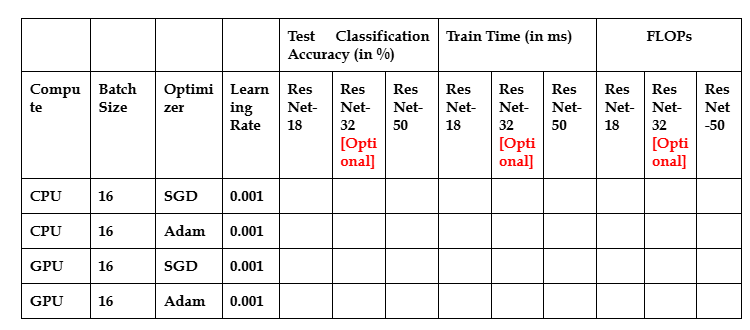

In [ ]:
!python train.py --config config.yaml --dataset fashionmnist --model resnet34 --batch_size 16 --epochs 20 --optimizer sgd --lr 0.001 --scheduler cosine --multi_seed 35 78 13


RUNNING WITH SEED: 35
Random seed set to: 35
TRAINING CONFIGURATION
CUDA not available, falling back to CPU
Device: cpu
100% 26.4M/26.4M [00:02<00:00, 11.7MB/s]
100% 29.5k/29.5k [00:00<00:00, 209kB/s]
100% 4.42M/4.42M [00:01<00:00, 3.92MB/s]
100% 5.15k/5.15k [00:00<00:00, 21.7MB/s]
Dataset: FASHIONMNIST (image_size=28)
  Train: 49000 samples (70%)
  Val:   7000 samples (10%)
  Test:  14000 samples (20%)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
Model: RESNET18
  Pretrained: False
  Output classes: 10
  Total parameters: 11,181,642
  FLOPs: 0.03G
Optimizer: SGD, LR: 0.001
/content

In [ ]:
!python train.py --config config.yaml --dataset fashionmnist --model resnet34 --batch_size 16 --epochs 20 --optimizer adam --lr 0.001 --scheduler cosine --multi_seed 35 78 13


RUNNING WITH SEED: 35
Random seed set to: 35
TRAINING CONFIGURATION
CUDA not available, falling back to CPU
Device: cpu
100% 26.4M/26.4M [00:01<00:00, 13.3MB/s]
100% 29.5k/29.5k [00:00<00:00, 201kB/s]
100% 4.42M/4.42M [00:01<00:00, 3.72MB/s]
100% 5.15k/5.15k [00:00<00:00, 22.9MB/s]
Dataset: FASHIONMNIST (image_size=28)
  Train: 49000 samples (70%)
  Val:   7000 samples (10%)
  Test:  14000 samples (20%)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
Model: RESNET34
  Pretrained: False
  Output classes: 10
  Total parameters: 21,289,802
  FLOPs: N/A (install thop)
Optimizer: ADAM, LR: 

Rest entries are taken from question 1 a) part

***FLOPs (Floating-Point Operations): required to perform a task, measuring model complexity. Independent on device this is ran***